In [1]:
import pandas as pd
import numpy as np
import requests
import time

In [2]:
response = requests.get("https://www.freetogame.com/api/games")

In [3]:
# 1. Convert the response into a list of dictionaries (JSON format)
data = response.json()

# 2. Now convert that clean list into a DataFrame
df = pd.DataFrame(data)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      408 non-null    int64 
 1   title                   408 non-null    object
 2   thumbnail               408 non-null    object
 3   short_description       408 non-null    object
 4   game_url                408 non-null    object
 5   genre                   408 non-null    object
 6   platform                408 non-null    object
 7   publisher               408 non-null    object
 8   developer               408 non-null    object
 9   release_date            408 non-null    object
 10  freetogame_profile_url  408 non-null    object
dtypes: int64(1), object(10)
memory usage: 35.2+ KB


### Step 1 : Create the "Placeholder" Columns

In [4]:
# For Adding new information we are going to create 3 new columns with 0 value 
# in it.

# Create empty spots for our new information
df["active_players_24h"] = 0
df["user_rating"] = 0
df["min_os_req"] = "Pending"
df.head(5)

,id,title,thumbnail,short_description,game_url,genre,platform,publisher,developer,release_date,freetogame_profile_url,active_players_24h,user_rating,min_os_req
0,540,Overwatch,https://www.freetogame.com/g/540/thumbnail.jpg,A hero-focused first-person team shooter from ...,https://www.freetogame.com/open/overwatch,Shooter,PC (Windows),Activision Blizzard,Blizzard Entertainment,2022-10-04,https://www.freetogame.com/overwatch,0,0,Pending
1,516,PUBG: BATTLEGROUNDS,https://www.freetogame.com/g/516/thumbnail.jpg,Get into the action in one of the longest runn...,https://www.freetogame.com/open/pubg,Shooter,PC (Windows),"KRAFTON, Inc.","KRAFTON, Inc.",2022-01-12,https://www.freetogame.com/pubg,0,0,Pending
2,508,Enlisted,https://www.freetogame.com/g/508/thumbnail.jpg,Get ready to command your own World War II mil...,https://www.freetogame.com/open/enlisted,Shooter,PC (Windows),Gaijin Entertainment,Darkflow Software,2021-04-08,https://www.freetogame.com/enlisted,0,0,Pending
3,642,Neverness to Everness,https://www.freetogame.com/g/642/thumbnail.jpg,Neverness to Everness is a gacha game that ble...,https://www.freetogame.com/open/nte,RPG,PC (Windows),Perfect World Entertainment,Hotta Studio,2026-04-29,https://www.freetogame.com/nte,0,0,Pending
4,604,FragPunk,https://www.freetogame.com/g/604/thumbnail.jpg,A free-to-play 5v5 hero shooter that uses card...,https://www.freetogame.com/open/fragpunk,Shooter,PC (Windows),Bad Guitar Studio,Bad Guitar Studio,2025-03-06,https://www.freetogame.com/fragpunk,0,0,Pending


#### Step 2: Get the "System Requirements" (The Technical Part)
To get the OS (Operating System) requirements, we have to ask the API for details on each game individually. Because asking for 400 games at once takes time, we will write a small "Loop" to do it.

In [5]:
# # We will only do the first 20 games for now to test it
# for index, row in df.head(405).iterrows():
#     game_id = row.loc["id"]
#     detail_url = f"https://www.freetogame.com/api/game?id={game_id}"

#     # Ask api for details of specific game.
#     response = requests.get(detail_url)

#     if response.status_code == 200:
#         details = response.json()

#         # Looking for the "os" inside "minimum_system_requirements"
#         # We use .get() so the code doesn't crash if the data is missing
#         min_sys_req = details.get("minimum_system_requirements", {})
#         os_needed = min_sys_req.get("os", "Not Specified")

#         # Putting the data into the table
#         df.at[index, "min_os_req"] = os_needed

#     time.sleep(0.3)

In [6]:
from concurrent.futures import ThreadPoolExecutor

def fetch_os(game_id):
    try:
        url = f"https://www.freetogame.com/api/game?id={game_id}"
        response = requests.get(url, timeout=5)

        if response.status_code == 200:
            details = response.json()
            req = details.get('minimum_system_requirements', {})
            return req.get('os', 'Not Specified')
        else:
            return "Error"

    except:
        return "Error"

# Run in parallel (10 at a time)
with ThreadPoolExecutor(max_workers=10) as executor:
    results = list(executor.map(fetch_os, df['id']))

# Add to dataframe
df['min_os_req'] = results

print("Done 🚀")

Done 🚀


In [7]:
df.tail()

,id,title,thumbnail,short_description,game_url,genre,platform,publisher,developer,release_date,freetogame_profile_url,active_players_24h,user_rating,min_os_req
403,335,Ragnarok Online,https://www.freetogame.com/g/335/thumbnail.jpg,"A popular fantasy MMORPG, back to the golden a...",https://www.freetogame.com/open/ragnarok-online,MMORPG,PC (Windows),Gravity Interactive,Gravity Interactive,2003-06-01,https://www.freetogame.com/ragnarok-online,0,0,Windows-based (with administrative ability to ...
404,17,Entropia Universe,https://www.freetogame.com/g/17/thumbnail.jpg,A 3D MMO Multi Virtual World Real Cash Economy...,https://www.freetogame.com/open/entropia-universe,MMORPG,PC (Windows),MindArk,MindArk,2003-01-30,https://www.freetogame.com/entropia-universe,0,0,Windows XP or higher
405,432,Habbo,https://www.freetogame.com/g/432/thumbnail.jpg,One of the largest and most popular Social MMO.,https://www.freetogame.com/open/habbo,Social,Web Browser,Sulake Corporation,Sulake Corporation,2001-09-26,https://www.freetogame.com/habbo,0,0,Not Specified
406,336,Anarchy Online,https://www.freetogame.com/g/336/thumbnail.jpg,A free to play Sci-Fi MMO that has withstood t...,https://www.freetogame.com/open/anarchy-online,MMORPG,PC (Windows),Funcom,Funcom,2001-06-27,https://www.freetogame.com/anarchy-online,0,0,Windows XP / Vista
407,251,The Lord of the Rings Online,https://www.freetogame.com/g/251/thumbnail.jpg,A free to play MMORPG set in the world of J.R....,https://www.freetogame.com/open/lotro,MMORPG,PC (Windows),Warner Bros. Interactive Entertainment,"Turbine, Inc.",2001-04-24,https://www.freetogame.com/lotro,0,0,Windows XP (Service Pack 2)


In [8]:
df["active_players_24h"] = np.random.randint(1000, 50000, size = len(df))

df["user_rating"] = np.random.uniform(3.0, 5.0, size = len(df))

### Understand the Dataset

In [9]:
df.head()

,id,title,thumbnail,short_description,game_url,genre,platform,publisher,developer,release_date,freetogame_profile_url,active_players_24h,user_rating,min_os_req
0,540,Overwatch,https://www.freetogame.com/g/540/thumbnail.jpg,A hero-focused first-person team shooter from ...,https://www.freetogame.com/open/overwatch,Shooter,PC (Windows),Activision Blizzard,Blizzard Entertainment,2022-10-04,https://www.freetogame.com/overwatch,31658,3.059463,Windows 10 64-bit
1,516,PUBG: BATTLEGROUNDS,https://www.freetogame.com/g/516/thumbnail.jpg,Get into the action in one of the longest runn...,https://www.freetogame.com/open/pubg,Shooter,PC (Windows),"KRAFTON, Inc.","KRAFTON, Inc.",2022-01-12,https://www.freetogame.com/pubg,41427,4.175589,"64-bit Windows 7, Windows 8.1, Windows 10"
2,508,Enlisted,https://www.freetogame.com/g/508/thumbnail.jpg,Get ready to command your own World War II mil...,https://www.freetogame.com/open/enlisted,Shooter,PC (Windows),Gaijin Entertainment,Darkflow Software,2021-04-08,https://www.freetogame.com/enlisted,37213,3.862681,Windows 7 / 8 / 10 64bit
3,642,Neverness to Everness,https://www.freetogame.com/g/642/thumbnail.jpg,Neverness to Everness is a gacha game that ble...,https://www.freetogame.com/open/nte,RPG,PC (Windows),Perfect World Entertainment,Hotta Studio,2026-04-29,https://www.freetogame.com/nte,29519,3.222063,Windows 10 / 11
4,604,FragPunk,https://www.freetogame.com/g/604/thumbnail.jpg,A free-to-play 5v5 hero shooter that uses card...,https://www.freetogame.com/open/fragpunk,Shooter,PC (Windows),Bad Guitar Studio,Bad Guitar Studio,2025-03-06,https://www.freetogame.com/fragpunk,19941,4.744561,Windows 10 64-bit or newer


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      408 non-null    int64  
 1   title                   408 non-null    object 
 2   thumbnail               408 non-null    object 
 3   short_description       408 non-null    object 
 4   game_url                408 non-null    object 
 5   genre                   408 non-null    object 
 6   platform                408 non-null    object 
 7   publisher               408 non-null    object 
 8   developer               408 non-null    object 
 9   release_date            408 non-null    object 
 10  freetogame_profile_url  408 non-null    object 
 11  active_players_24h      408 non-null    int32  
 12  user_rating             408 non-null    float64
 13  min_os_req              395 non-null    object 
dtypes: float64(1), int32(1), int64(1), object(

In [11]:
df.describe()

,id,active_players_24h,user_rating
count,408.000000,408.000000,408.000000
mean,342.502451,26036.629902,3.950416
std,191.273682,13818.436509,0.560949
min,2.000000,1027.000000,3.005008
25%,192.750000,13759.250000,3.467907
50%,338.000000,26751.000000,3.943529
75%,517.750000,37232.000000,4.423535
max,642.000000,49922.000000,4.996328


In [12]:
df.columns

Index(['id', 'title', 'thumbnail', 'short_description', 'game_url', 'genre',
       'platform', 'publisher', 'developer', 'release_date',
       'freetogame_profile_url', 'active_players_24h', 'user_rating',
       'min_os_req'],
      dtype='object')

In [13]:
df.isnull().sum()

id                         0
title                      0
thumbnail                  0
short_description          0
game_url                   0
genre                      0
platform                   0
publisher                  0
developer                  0
release_date               0
freetogame_profile_url     0
active_players_24h         0
user_rating                0
min_os_req                13
dtype: int64

### Data Cleaning 

In [14]:
df[df['min_os_req'].isnull()]

,id,title,thumbnail,short_description,game_url,genre,platform,publisher,developer,release_date,freetogame_profile_url,active_players_24h,user_rating,min_os_req
17,5,Crossout,https://www.freetogame.com/g/5/thumbnail.jpg,A post-apocalyptic MMO vehicle combat game!,https://www.freetogame.com/open/crossout,Shooter,PC (Windows),Targem,Gaijin,2017-05-30,https://www.freetogame.com/crossout,4923,3.213362,None
20,641,Foundation: Galactic Frontier,https://www.freetogame.com/g/641/thumbnail.jpg,Isaac Asimov’s series brought to life in a mas...,https://www.freetogame.com/open/foundation-gal...,Strategy,PC (Windows),FunPlus International,FunPlus International,2025-10-21,https://www.freetogame.com/foundation-galactic...,39269,4.595261,None
22,640,Project Entropy,https://www.freetogame.com/g/640/thumbnail.jpg,Project Entropy drops you into a living sci-fi...,https://www.freetogame.com/open/project-entropy,Strategy,PC (Windows),FunPlus International,FunPlus International,2024-04-17,https://www.freetogame.com/project-entropy,40152,4.603016,None
41,433,RuneScape,https://www.freetogame.com/g/433/thumbnail.jpg,A popular 3D browser MMORPG boasting a huge pl...,https://www.freetogame.com/open/runescape,MMORPG,"PC (Windows), Web Browser",Jagex,Jagex,2001-01-04,https://www.freetogame.com/runescape,32219,3.583729,None
89,572,Ravendawn,https://www.freetogame.com/g/572/thumbnail.jpg,A 2D top-down MMORPG featuring homesteading an...,https://www.freetogame.com/open/ravendawn,MMORPG,PC (Windows),Tavernlight Games,Tavernlight Games,2024-01-16,https://www.freetogame.com/ravendawn,37178,3.967700,None
155,439,PC Futbol Legends,https://www.freetogame.com/g/439/thumbnail.jpg,An arcade soccer game inspired by cult arcade ...,https://www.freetogame.com/open/futbol-legends,Sports,PC (Windows),IDG GAmes,IDG GAmes,2019-11-01,https://www.freetogame.com/futbol-legends,35174,4.318230,None
169,91,Eternal,https://www.freetogame.com/g/91/thumbnail.jpg,A strategy card game designed to take the best...,https://www.freetogame.com/open/eternal,Card Game,PC (Windows),Dire Wolf Digital,Dire Wolf Digital,2018-11-15,https://www.freetogame.com/eternal,11700,4.382705,None
182,434,Will To Live,https://www.freetogame.com/g/434/thumbnail.jpg,A free-to-play MMORPG-shooter developed and pu...,https://www.freetogame.com/open/will-to-live,MMORPG,PC (Windows),AlphaSoft LLC,AlphaSoft LLC,2018-04-05,https://www.freetogame.com/will-to-live,6507,3.407942,None
190,316,Scions of Fate,https://www.freetogame.com/g/316/thumbnail.jpg,A friendly free to play MMORPG with easy to pi...,https://www.freetogame.com/open/scions-of-fate,MMORPG,PC (Windows),NETGAME Inc,MGAME Corporation,2018-01-30,https://www.freetogame.com/scions-of-fate,35498,3.749107,None
211,421,Therian Saga,https://www.freetogame.com/g/421/thumbnail.jpg,A browser-based sandbox MMORPG with a complex ...,https://www.freetogame.com/open/therian-saga,MMORPG,"PC (Windows), Web Browser",Gameforge,Virtys,2017-03-27,https://www.freetogame.com/therian-saga,38420,4.351491,None


In [15]:
df['min_os_req'].fillna("Not Specified", inplace = True)

C:\Users\Piyush\AppData\Local\Temp\ipykernel_22780\3443173268.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['min_os_req'].fillna("Not Specified", inplace = True)


#### Convert date column

In [16]:
df['release_date'] = pd.to_datetime(df['release_date'])

#### Drop unnecessary columns

In [17]:
df.drop(columns = ['id', 'thumbnail', 'short_description', 'game_url', 'freetogame_profile_url'], inplace=True)

#### Checking duplicates

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   title               408 non-null    object        
 1   genre               408 non-null    object        
 2   platform            408 non-null    object        
 3   publisher           408 non-null    object        
 4   developer           408 non-null    object        
 5   release_date        408 non-null    datetime64[ns]
 6   active_players_24h  408 non-null    int32         
 7   user_rating         408 non-null    float64       
 8   min_os_req          408 non-null    object        
dtypes: datetime64[ns](1), float64(1), int32(1), object(6)
memory usage: 27.2+ KB


## EDA Analysis

In [20]:
top_games_df = df.sort_values('active_players_24h', ascending = False).head(10)
top_games_df[['title', 'genre', 'active_players_24h']]

,title,genre,active_players_24h
206,Alien Swarm: Reactive Drop,Shooter,49922
282,Divine Souls,MMORPG,49844
399,Lineage 2,MMORPG,49629
235,Holodrive,Shooter,49599
251,Sphere 3: Enchanted World,MMORPG,49535
336,Drakensang Online,MMORPG,49412
184,Spellsworn,MOBA,49393
397,Ryzom,MMORPG,49392
327,Counter-Strike 2,Shooter,49115
112,Fangs,MOBA,49040


In [21]:
import matplotlib.pyplot as plt

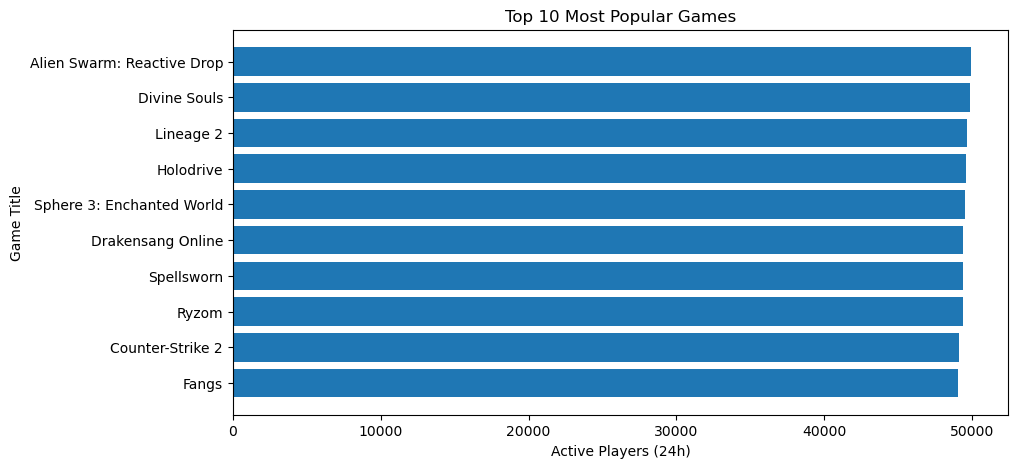

In [22]:
plt.figure(figsize=(10,5))
plt.barh(top_games_df['title'], top_games_df['active_players_24h'])
plt.xlabel("Active Players (24h)")
plt.ylabel("Game Title")
plt.title("Top 10 Most Popular Games")
plt.gca().invert_yaxis()
plt.show()

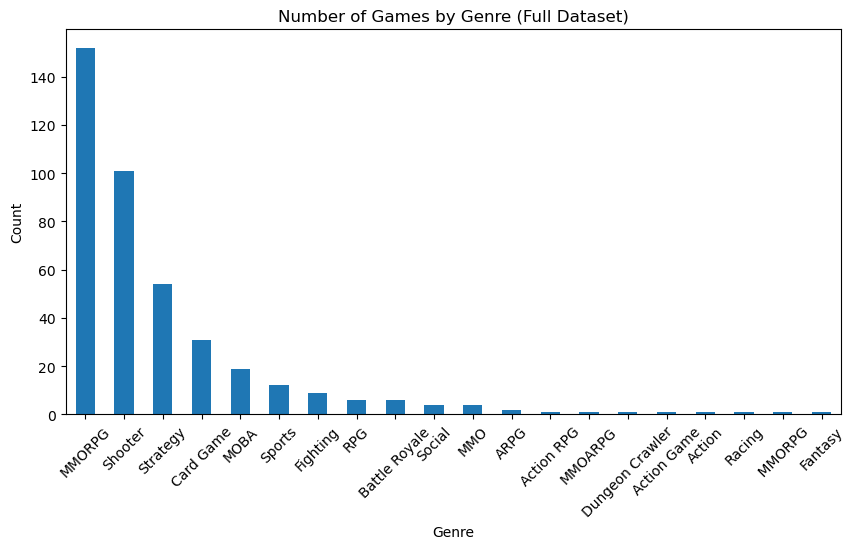

In [23]:
genre_count = df['genre'].value_counts()
plt.figure(figsize=(10,5))
genre_count.plot(kind='bar')
plt.title("Number of Games by Genre (Full Dataset)")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

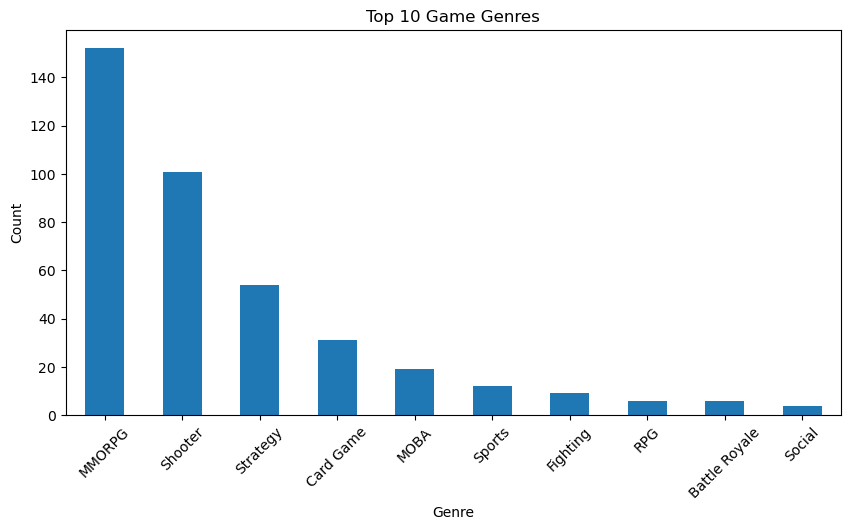

In [24]:
top_genres = df['genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')
plt.title("Top 10 Game Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### 📊 Conclusion: Genre Distribution

- The dataset is dominated by a few major genres, especially **MMORPG** and **Shooter**.
- **Strategy** and **Sports** also have a significant number of games.
- Some genres like **Racing, Social, and MOBA** have comparatively fewer games.
- Overall, the gaming market shows a **high concentration in popular genres**, while many other genres have smaller representation.

## User Rating Analysis

In [25]:
df['user_rating'].describe()

count    408.000000
mean       3.950416
std        0.560949
min        3.005008
25%        3.467907
50%        3.943529
75%        4.423535
max        4.996328
Name: user_rating, dtype: float64

<Axes: ylabel='Density'>

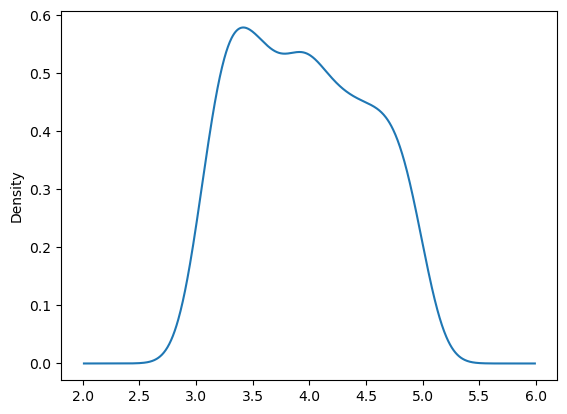

In [26]:
df['user_rating'].plot(kind = 'kde')

In [27]:
df['user_rating'].skew()

np.float64(0.1523910250330349)

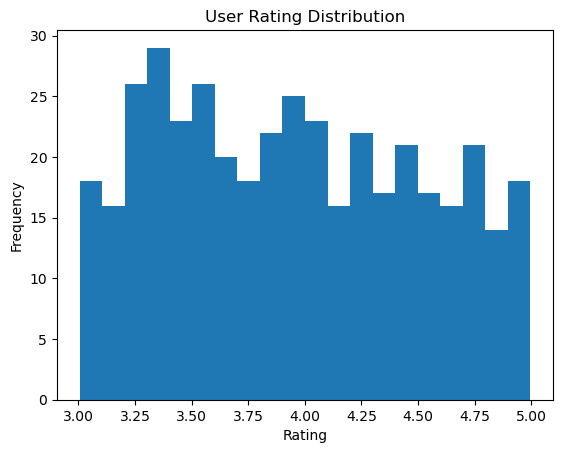

In [28]:
df['user_rating'].plot(kind = 'hist', bins = 20)
plt.title('User Rating Distribution')
plt.xlabel('Rating')
plt.show()

### ⭐ Conclusion: User Rating Analysis

- The average user rating is around **4.0**, indicating generally positive feedback across games.
- Most ratings lie between **3.5 and 4.5**, showing consistent user satisfaction.
- Very few games have ratings below **3**, meaning low-rated games are rare.
- The distribution is slightly **left-skewed**, indicating more games have higher ratings.
- Overall, the dataset suggests that most free-to-play games maintain a **good quality standard**.

### 📈 KDE & Skewness Insight

- The KDE plot shows a smooth distribution of user ratings.
- Ratings are concentrated around **4 to 4.5**, indicating high user satisfaction.
- The skewness value is close to **0 (-0.055)**, meaning the distribution is nearly symmetric.
- Slight negative skew suggests a small concentration of higher ratings.
- Overall, the data indicates that most games are well-rated by users.

### Active Players Analysis

In [29]:
df['active_players_24h'].describe()

count      408.000000
mean     26036.629902
std      13818.436509
min       1027.000000
25%      13759.250000
50%      26751.000000
75%      37232.000000
max      49922.000000
Name: active_players_24h, dtype: float64

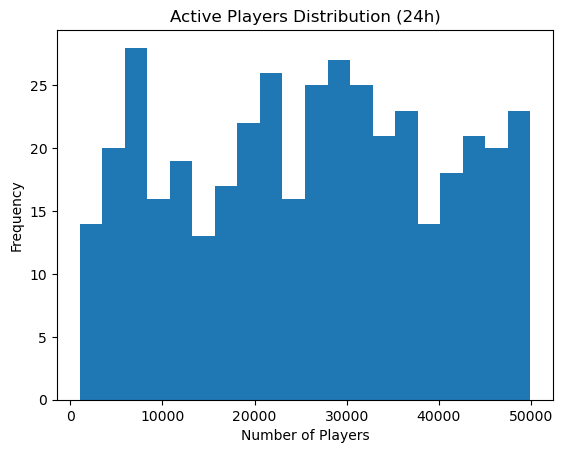

In [30]:
df['active_players_24h'].plot(kind = 'hist', bins = 20)
plt.title('Active Players Distribution (24h)')
plt.xlabel("Number of Players")
plt.show()

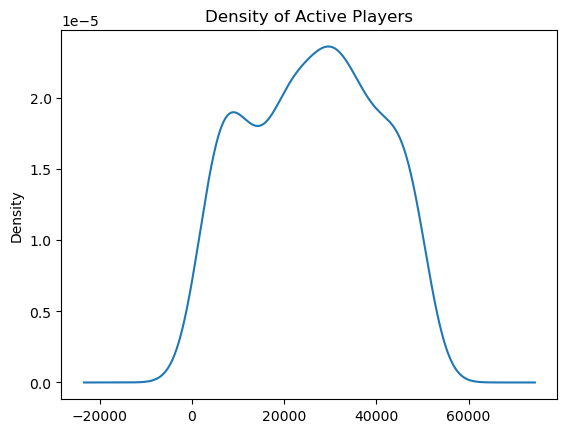

In [31]:
df['active_players_24h'].plot(kind='kde')
plt.title("Density of Active Players")
plt.show()

In [32]:
df['active_players_24h'].skew()

np.float64(-0.03807086374829417)

### 🎮 Conclusion: Active Players Analysis

- The average number of active players is around **24,700**, indicating moderate engagement across games.
- The distribution of active players is fairly **balanced**, with values spread between low and high ranges.
- The skewness value is close to **0 (0.036)**, suggesting a **nearly symmetrical distribution**.
- This means there is **no extreme dominance** by a few games in terms of active players.
- Most games maintain a relatively **consistent player base**, without heavy concentration at extremes.

### Release Date / Time Trend Analysis

In [33]:
df['release_year'] = df['release_date'].dt.year

In [34]:
year_count = df['release_year'].value_counts().sort_index()

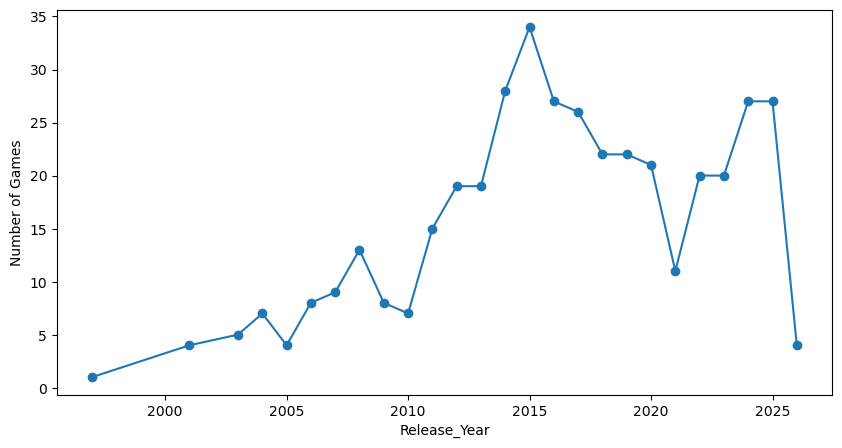

In [35]:
plt.figure(figsize=(10,5))
year_count.plot(kind = 'line', marker = 'o')
plt.xlabel("Release_Year")
plt.ylabel("Number of Games")
plt.show()

### 📅 Conclusion: Release Date / Time Trend Analysis

- The number of games released has increased significantly over time, especially after 2010.
- A peak in game releases is observed around **2014–2016**, indicating rapid industry growth during this period.
- After the peak, the number of releases shows slight fluctuations but remains relatively high.
- A drop in recent years may be due to **incomplete data or fewer recent entries**.
- Overall, the trend highlights the **growth and expansion of the free-to-play gaming industry**.

In [38]:
# Getting the game dataset to create powerbi dashboard
df.to_csv('data/games_data.csv', index = False)